2025-03-11 12:04:33.039 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


MSE: 281.12633552110145, R-squared: 0.818217630839638


2025-03-11 12:04:33.536 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-03-11 12:04:33.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:04:33.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:04:33.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:04:33.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:04:33.552 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:04:33.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:04:34.122 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 

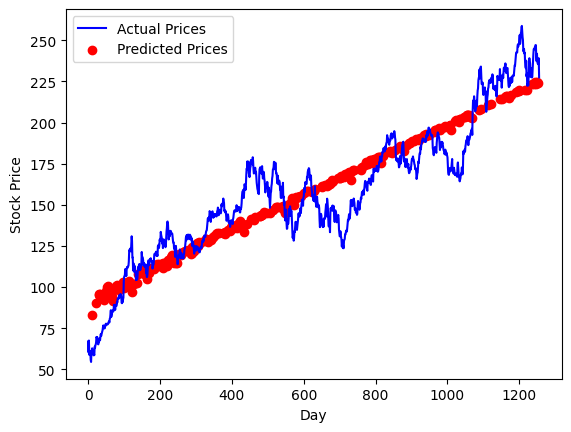

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import streamlit as st

# Fetch stock data
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(period='5y')
    df = df[['Close', 'Volume']].dropna()
    df['Day'] = np.arange(len(df))
    return df

# Load dataset
ticker = 'AAPL'  # Example stock symbol
df = get_stock_data(ticker)

# Define features and target variable
X = df[['Day', 'Volume']]
y = df['Close']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}, R-squared: {r2}')

# Streamlit app for visualization
st.title('Stock Price Trend Prediction')
st.write(f'Stock: {ticker}')

fig, ax = plt.subplots()
ax.plot(df['Day'], df['Close'], label='Actual Prices', color='blue')
ax.scatter(X_test['Day'], y_pred, label='Predicted Prices', color='red')
ax.set_xlabel('Day')
ax.set_ylabel('Stock Price')
ax.legend()
st.pyplot(fig)

# Prediction function
def predict_stock_price(day, volume):
    input_data = np.array([day, volume]).reshape(1, -1)
    return model.predict(input_data)[0]

# User input for prediction
st.sidebar.header('Predict Future Stock Price')
day = st.sidebar.number_input('Enter Future Day:',
min_value=int(df['Day'].min()), max_value=int(df['Day'].max())+30)
volume = st.sidebar.number_input('Enter Expected Volume:',
min_value=int(df['Volume'].min()), max_value=int(df['Volume'].max()))

if st.sidebar.button('Predict'):
    prediction = predict_stock_price(day, volume)
    st.sidebar.write(f'Predicted Stock Price: ${prediction:.2f}')